In [18]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
import matplotlib.pyplot as plt

# Load data

In [2]:
import sys
sys.path.append('../')
from src.data_loader import load_paysim_data
df = load_paysim_data('D:/Công việc/DA + DE/Book DA/Data Science for Business/PaySim/fraud-detection-paysim/data/raw/Synthetic_Financial_datasets_log.csv')
df.info()

--- Đang tải dữ liệu từ: D:/Công việc/DA + DE/Book DA/Data Science for Business/PaySim/fraud-detection-paysim/data/raw/Synthetic_Financial_datasets_log.csv ---
Bộ nhớ tiêu thụ ban đầu: 533.97 MB
Bộ nhớ tiêu thụ sau tối ưu: 248.78 MB
Tiết kiệm được: 53.4%
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype   
---  ------          -----   
 0   step            int16   
 1   type            category
 2   amount          float32 
 3   nameOrig        object  
 4   oldbalanceOrg   float32 
 5   newbalanceOrig  float32 
 6   nameDest        object  
 7   oldbalanceDest  float32 
 8   newbalanceDest  float32 
 9   isFraud         int8    
 10  isFlaggedFraud  int8    
dtypes: category(1), float32(5), int16(1), int8(2), object(2)
memory usage: 248.8+ MB


# FEATURE ENGINEERING

Hour + isFraud: Hoạt động liên tục (không theo thời gian sinh học) 

In [22]:
df['hour_of_day'] = df['step'] % 24
df['is_night'] = ((df['hour_of_day'] < 6) | (df['hour_of_day'] > 22)).astype(int)

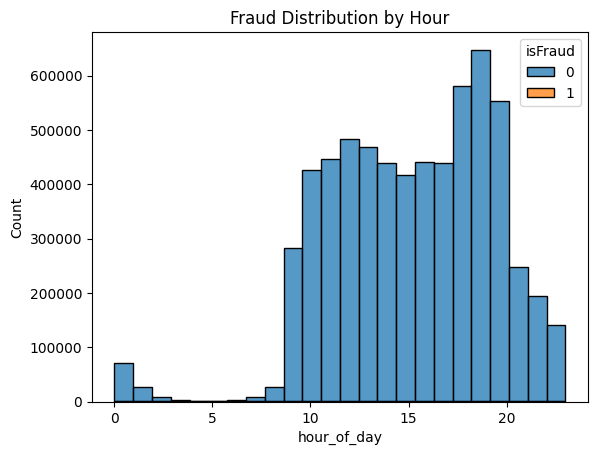

In [23]:
sns.histplot(data=df, x='hour_of_day', hue='isFraud', bins=24, multiple='stack')
plt.title("Fraud Distribution by Hour")
plt.show()

Type + isFraud: Tập trung vào TRANSFER → CASH_OUT

In [4]:
type_fraud_stats = df.groupby('type')['isFraud'].agg(['count','sum'])
type_fraud_stats.columns = ['Tổng số giao dịch', 'Số vụ gian lận']
type_fraud_stats['Tỷ lệ gian lận (%)'] = (type_fraud_stats['Số vụ gian lận'] / type_fraud_stats['Tổng số giao dịch']) * 100

print (type_fraud_stats.sort_values(by='Số vụ gian lận', ascending=False))

          Tổng số giao dịch  Số vụ gian lận  Tỷ lệ gian lận (%)
type                                                           
CASH_OUT            2237500            4116            0.183955
TRANSFER             532909            4097            0.768799
CASH_IN             1399284               0            0.000000
DEBIT                 41432               0            0.000000
PAYMENT             2151495               0            0.000000


C:\Users\admin\AppData\Local\Temp\ipykernel_14968\2323943806.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  type_fraud_stats = df.groupby('type')['isFraud'].agg(['count','sum'])


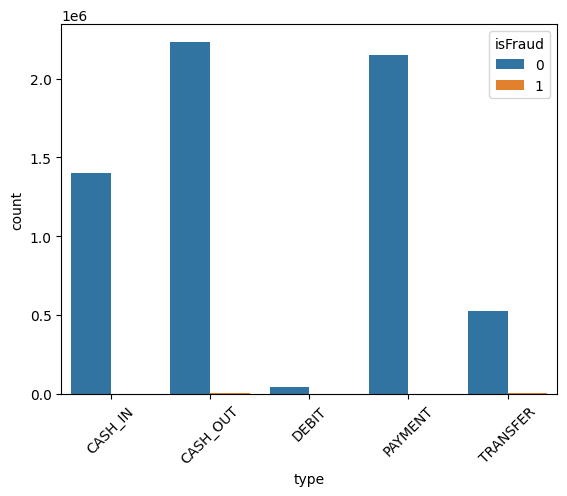

In [24]:
sns.countplot(data=df, x='type', hue='isFraud')
plt.xticks(rotation=45)
plt.show()

In [31]:
df['is_high_risk_type'] = df['type'].isin(['TRANSFER', 'CASH_OUT']).astype(int)

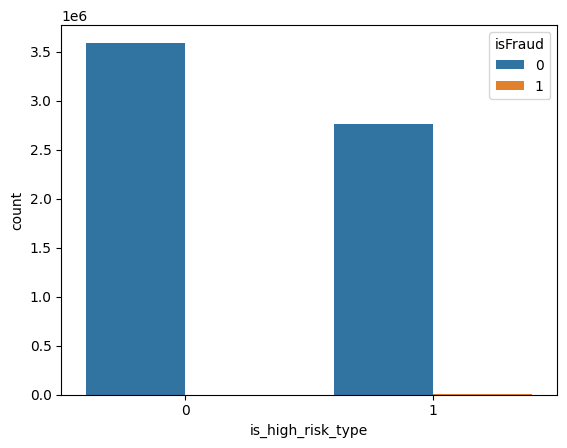

In [32]:
sns.countplot(data=df, x='is_high_risk_type', hue='isFraud')
plt.show()

Amount + isFraud: Giá trị giao dịch lớn

In [6]:
stats = df.groupby('isFraud')['amount'].agg(['mean', 'median', 'max', 'min'])
print(stats)

                 mean        median         max   min
isFraud                                              
0        1.781970e+05   74684.71875  92445520.0  0.01
1        1.467967e+06  441423.43750  10000000.0  0.00


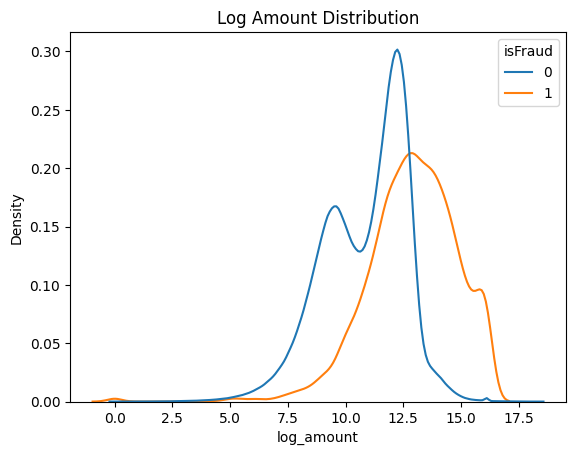

In [25]:
df['log_amount'] = np.log1p(df['amount'])

sns.kdeplot(data=df, x='log_amount', hue='isFraud', common_norm=False)
plt.title("Log Amount Distribution")
plt.show()

oldbalanceDest vs isFraud: Nhắm vào tài khoản nhận “rỗng” hoặc mới tạo


In [ ]:
df['dest_has_history'] = df['oldbalanceDest'].apply(lambda x: 'Có lịch sử (>0)' if x > 0 else 'Trắng (0.0)')
history_stats = pd.crosstab(df['dest_has_history'], df['isFraud'],normalize='index') * 100
print(history_stats)

isFraud                   0         1
dest_has_history                     
Có lịch sử (>0)   99.921765  0.078235
Trắng (0.0)       99.802136  0.197864


In [26]:
df['is_dest_zero_balance'] = (df['oldbalanceDest'] == 0).astype(int)

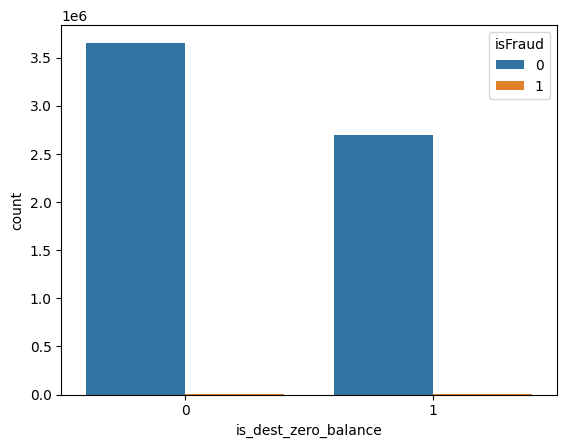

In [27]:
sns.countplot(data=df, x='is_dest_zero_balance', hue='isFraud')
plt.show()

isFraud + orig_error + dest_error:Phá vỡ logic số dư để qua mặt hệ thống kiểm soát

In [ ]:
# Biến Sai số nguồn: Số dư cũ - Số tiền chuyển - Số dư mới = 0 -> True
df['org_error'] = df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']
# Biến Sai số đích: Số dư cũ + Số tiền nhận - Số dư mới = 0 --> True
df['dest_error'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

In [28]:
df['is_balance_error'] = (
    (df['org_error'] != 0) | (df['dest_error'] != 0)
).astype(int)

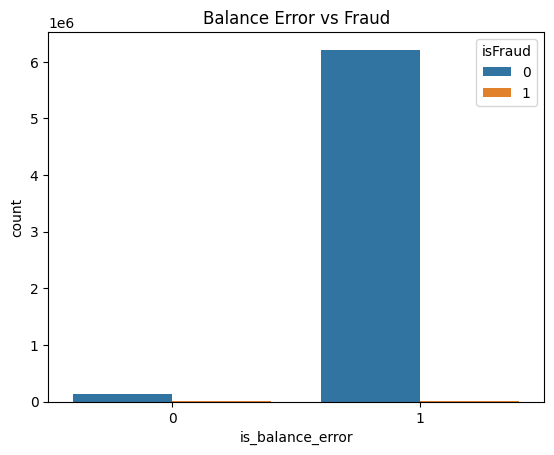

In [29]:
sns.countplot(data=df, x='is_balance_error', hue='isFraud')
plt.title("Balance Error vs Fraud")
plt.show()

isFlaggedFraud + type và isFlaggedFraud + amount: Không bị phát hiện bởi rule-based system và chỉ bị phát hiện khi transder trên 350k

In [10]:
min_amount_flagged = df[df['isFlaggedFraud'] == 1]['amount'].min()
types_flagged = df[df['isFlaggedFraud'] == 1]['type'].unique()

print(f"Số tiền nhỏ nhất bị hệ thống cũ bắt: {min_amount_flagged:,.0f}")
print(f"Các loại giao dịch bị hệ thống cũ bắt: {types_flagged}")

Số tiền nhỏ nhất bị hệ thống cũ bắt: 353,874
Các loại giao dịch bị hệ thống cũ bắt: ['TRANSFER']
Categories (5, object): ['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER']


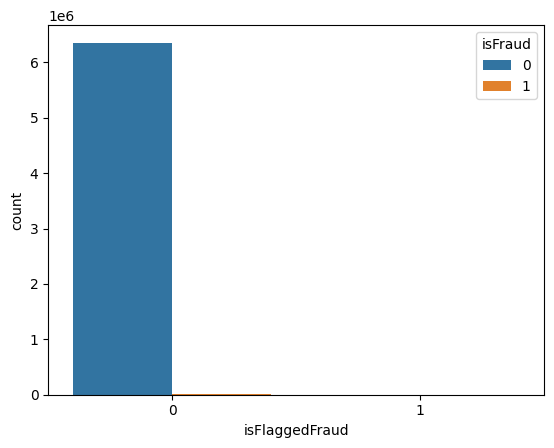

In [30]:
sns.countplot(data=df, x='isFlaggedFraud', hue='isFraud')
plt.show()